# **Processing image data**

In [ ]:
import pyreadr # for reading .RData files
import pandas as pd
import fitz # for reading .pdf files
import os
from tqdm import tqdm #for progress bars
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import polars as pl
import subprocess, time

In [2]:
# Read the metadata from the RDS file, name the resulting dataframe 'gri'
result = pyreadr.read_r("DAV_assignment.rds")
gri = list(result.values())[0]
type(gri)
gri["Year"] = gri["Year"].astype(int)
gri['pdf_basename'] = gri['file'] + '.pdf' # Create a new column for the PDF file name
gri['have_pdf'] = False # Create a new column to indicate if the PDF file is available
gri['have_pdf'] = gri['have_pdf'].astype(bool) # Ensure the 'have_pdf' column is of boolean type
gri.head()

,Name,Year,file,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english,pdf_basename,have_pdf
0,Procter & Gamble,1999,Procter&Gamble_1999,NaN,Large,Household and Personal Products,Consumer Goods,United States of America,Northern America,NaN,english,Procter&Gamble_1999.pdf,False
1,Banrisul,2000,Banrisul_2000,NaN,Large,Financial Services,Financials,Brazil,Latin America & the Caribbean,NaN,non-english,Banrisul_2000.pdf,False
2,Hitachi High-Technologies Corp.,2000,HitachiHigh-TechnologiesCorp._2000,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,HitachiHigh-TechnologiesCorp._2000.pdf,False
3,Procter & Gamble,2000,Procter&Gamble_2000,NaN,Large,Household and Personal Products,Consumer Goods,United States of America,Northern America,NaN,english,Procter&Gamble_2000.pdf,False
4,Vancity,2000,Vancity_2000,NaN,Large,Financial Services,Financials,Canada,Northern America,NaN,english,Vancity_2000.pdf,False


In [3]:
# Folder containing the PDF files
dir_pdf = "C:/Users/Thu Huong/OneDrive/pdf_converted"

# Get PDF files
all_pdf_files = os.listdir(dir_pdf)
available_pdf_files = []

# Filter only records that have a corresponding PDF file
for file in tqdm(gri['pdf_basename']):
    if file in all_pdf_files:
        available_pdf_files.append(file)
        gri.loc[gri['pdf_basename'] == file, 'have_pdf'] = True
    else:
        continue

gri_pdf = gri[gri['have_pdf'] == True]
gri_pdf.head()

100%|██████████| 19040/19040 [00:43<00:00, 439.37it/s] 


,Name,Year,file,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english,pdf_basename,have_pdf
1,Banrisul,2000,Banrisul_2000,NaN,Large,Financial Services,Financials,Brazil,Latin America & the Caribbean,NaN,non-english,Banrisul_2000.pdf,True
14,Canfor Corp.,2002,CanforCorp._2002,NaN,MNE,Forest and Paper Products,Renewable Resources & Alternative Energy,Canada,Northern America,NaN,english,CanforCorp._2002.pdf,True
16,JFE Holdings,2002,JFEHoldings_2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
19,Ricoh,2002,Ricoh_2002,NaN,MNE,Technology Hardware,Technology and Communications,Japan,Asia,NaN,english,Ricoh_2002.pdf,True
25,Westpac Banking Corporation,2002,WestpacBankingCorporation_2002,NaN,MNE,Financial Services,Financials,Australia,Oceania,NaN,english,WestpacBankingCorporation_2002.pdf,True


In [4]:
# Demographics of the GRI reports
gri_years = gri_pdf.groupby(['Year','Sector']).agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()
gri_size = gri_pdf.groupby(['Size','Sector']).agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()
gri_region = gri_pdf.groupby(['Region','Sector']).agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()

gri_region.pivot(index='Sector', columns='Region', values='count')

Region,Africa,Asia,Europe,Latin America & the Caribbean,Northern America,Oceania
Sector,,,,,,
Agriculture,NaN,20.0,13.0,12.0,4.0,NaN
Automotive,NaN,128.0,23.0,4.0,5.0,1.0
Aviation,1.0,46.0,9.0,6.0,5.0,1.0
Chemicals,NaN,280.0,25.0,8.0,17.0,NaN
Commercial Services,NaN,33.0,43.0,11.0,13.0,NaN
Computers,NaN,54.0,9.0,1.0,9.0,NaN
Conglomerates,1.0,131.0,14.0,6.0,3.0,1.0
Construction,2.0,146.0,26.0,8.0,7.0,NaN
Construction Materials,3.0,89.0,30.0,6.0,1.0,NaN


### **Extracting images from pdf files**
- Step 1: Create folder to store images csv result files
- Step 2: Create the helper functions to download files from onedrive and upload back.
- Step 3: Create a function ***extract_images_from_pdfs()*** to extract images from pdf files
- Step 4: Run the function for the selected subset of report (run once and it takess about 2 hours)
  => Extracted images will be saved to folder and images_meta data will be saved into csv file "extracted_images_metadata.csv"
- Step 5: Open and read the csv file and use it for further analysis

In [5]:
dir_image = "data/image"
dir_results = "data/results" # Directory to store analysis results (.csv files)

# Create the image directory if it doesn't exist
os.makedirs(dir_image, exist_ok=True)
# Create the results directory if it doesn't exist
os.makedirs(dir_results, exist_ok=True)

In [6]:
# Define helper functions for OneDrive file handling
'''def pin_file(path):
    """Force OneDrive to download this file (make it always available offline)"""
    subprocess.run(["attrib", "+p", str(path)], check=False, capture_output=True, text=True)''' #no longer needed

'''def wait_until_downloaded(path, timeout=180, poll=2):
    """Wait for file to be fully downloaded"""
    start = time.time()
    last_size = -1
    stable = 0
    while time.time() - start < timeout:
        try:
            size = path.stat().st_size
            if size > 0 and size == last_size:
                stable += 1
            else:
                stable = 0
            last_size = size
            if size > 0 and stable >= 2:  # File size stable for 2 checks
                return True
        except Exception:
            pass
        time.sleep(poll)
    return False''' #no longer needed since we are not pinning files

def unpin_file(path):
    """Free up space by making it online-only again"""
    subprocess.run(["attrib", "-p", "+u", str(path)], check=False, capture_output=True, text=True)

In [7]:
def extract_images_from_pdfs(selected_files, selected_gri):
    # Create a list to store the extracted images and their metadata from gri
    images = []

    for file in tqdm(selected_files, desc="Processing PDFs"):
        # Construct the full path to the PDF file
        pdf_path = os.path.join(dir_pdf, file)

        # Find the corresponding metadata in selected_gri for the current PDF file
        meta = selected_gri[selected_gri['pdf_basename'] == file]
        meta_row = meta.iloc[0].to_dict() 

        try:
            # Step 1: Download the PDF file from OneDrive
            #pin_file(pdf_path)

            # Step 2: Wait for the PDF file to be fully downloaded
            #if not wait_until_downloaded(pdf_path, timeout=180, poll=2):
            #    print(f"Timed out waiting for download for {file}")
            #    continue

            # Step 3: Try to open the PDF file using fitz
            doc = fitz.open(pdf_path)

            # Step 4: Loop through each page in the PDF
            for page_num in range(len(doc)):
                page = doc[page_num]
                
                # Extract images from the page
                try:
                    image_list = page.get_images(full=True)
                except Exception as e:
                    print(f"Error extracting images from page {page_num+1} of {file}: {e}")
                    continue

                if len(image_list) == 20:
                    continue # Skip pages with 20 images
                
                # Loop through each image found on the page
                for img_index, img in enumerate(image_list):
                    try:
                        xref = img[0]
                        base_image = doc.extract_image(xref)
                        image_bytes = base_image["image"]
                        image_ext = base_image["ext"]
                        image_width = base_image["width"]
                        image_height = base_image["height"]
                        if image_width < 100 or image_height < 100:
                            continue # Skip small images that are too small and likely not relevant

                        # Create a unique filename for the extracted image
                        image_filename = f"{os.path.splitext(file)[0]}_page{page_num+1}_img{img_index+1}.{image_ext}"
                        image_path = os.path.join(dir_image, image_filename)
                        
                        # Save the extracted image to the specified directory
                        with open(image_path, "wb") as img_file:
                            img_file.write(image_bytes)
                        
                        # Append the extracted image and its metadata to the list
                        images.append({
                            "file": file,
                            "page": page_num + 1,
                            "image_index": img_index + 1,
                            "image_path": image_path,
                            "image_filename": image_filename,
                            "width": image_width,
                            "height": image_height,
                            **meta_row
                        })
                    except Exception as e:
                        print(f"Error processing image {img_index+1} on page {page_num+1} of {file}: {e}")
                        continue
            
            doc.close()
        except Exception as e:
            print(f"Error processing {file}: {e}")
            continue
        finally:
            # Step 5: Free up local disk space again (make it online-only)
            unpin_file(pdf_path)
    # Convert the list of images and their metadata into a DataFrame
    images_df = pd.DataFrame(images)
    print(f"Successfully extracted {len(images_df)} images!")
    print(f"Images saved to: {dir_image}")
    print("\nFirst few rows:")
    print(images_df.head())

    # Optional: Save the metadata to CSV
    images_df.to_csv(os.path.join(dir_results, "extracted_images_metadata.csv"), index=False)

    return images_df


In [8]:
# Select only the records in the 'Conglomerates' sector
selected_files = gri_pdf[gri_pdf['Sector']=='Conglomerates']['pdf_basename'].tolist()
selected_gri = gri_pdf[gri_pdf['Sector']=='Conglomerates']

In [9]:
selected_gri

,Name,Year,file,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english,pdf_basename,have_pdf
16,JFE Holdings,2002,JFEHoldings_2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
251,UNITIKA,2006,UNITIKA_2006,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,non-english,UNITIKA_2006.pdf,True
446,UNITIKA,2007,UNITIKA_2007,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,UNITIKA_2007.pdf,True
453,Wiener Stadtwerke,2007,WienerStadtwerke_2007,NaN,Large,Conglomerates,Conglomerates,Austria,Europe,NaN,non-english,WienerStadtwerke_2007.pdf,True
593,Keikyu,2008,Keikyu_2008,NaN,Large,Conglomerates,Conglomerates,Japan,Asia,NaN,non-english,Keikyu_2008.pdf,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18946,Yasar Holding,2017,YasarHolding_2017,Private company,Large,Conglomerates,Conglomerates,Turkey,Asia,No,non-english,YasarHolding_2017.pdf,True
18980,Zhejiang Hangmin Stock,2017,ZhejiangHangminStock_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,No,non-english,ZhejiangHangminStock_2017.pdf,True
18984,Zhejiang Jiahua Energy Chemical Industry,2017,ZhejiangJiahuaEnergyChemicalIndustry_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZhejiangJiahuaEnergyChemicalIndustry_2017.pdf,True
18987,Zhejiang Longsheng Group,2017,ZhejiangLongshengGroup_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZhejiangLongshengGroup_2017.pdf,True


In [10]:
# Call the function to extract images from PDFs (run once to save the results, then comment out to avoid re-running)
#images_df = extract_images_from_pdfs(selected_files, selected_gri)

# Read the extracted images metadata from CSV 
images_df = pd.read_csv(os.path.join(dir_results, "extracted_images_metadata.csv"))
images_df

,file,page,image_index,image_path,image_filename,width,height,Name,Year,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english,pdf_basename,have_pdf
0,JFEHoldings_2002,1,1,data/image\JFEHoldings_2002_page1_img1.jpeg,JFEHoldings_2002_page1_img1.jpeg,117,153,JFE Holdings,2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
1,JFEHoldings_2002,1,2,data/image\JFEHoldings_2002_page1_img2.jpeg,JFEHoldings_2002_page1_img2.jpeg,117,153,JFE Holdings,2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
2,JFEHoldings_2002,1,3,data/image\JFEHoldings_2002_page1_img3.jpeg,JFEHoldings_2002_page1_img3.jpeg,843,985,JFE Holdings,2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
3,JFEHoldings_2002,3,1,data/image\JFEHoldings_2002_page3_img1.jpeg,JFEHoldings_2002_page3_img1.jpeg,542,400,JFE Holdings,2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
4,JFEHoldings_2002,4,1,data/image\JFEHoldings_2002_page4_img1.jpeg,JFEHoldings_2002_page4_img1.jpeg,1293,267,JFE Holdings,2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12857,ZHONGSHANBROAD-OCEANMOTOR_2017,22,5,data/image\ZHONGSHANBROAD-OCEANMOTOR_2017_page...,ZHONGSHANBROAD-OCEANMOTOR_2017_page22_img5.jpeg,592,333,ZHONGSHAN BROAD-OCEAN MOTOR,2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZHONGSHANBROAD-OCEANMOTOR_2017.pdf,True
12858,ZHONGSHANBROAD-OCEANMOTOR_2017,22,6,data/image\ZHONGSHANBROAD-OCEANMOTOR_2017_page...,ZHONGSHANBROAD-OCEANMOTOR_2017_page22_img6.jpeg,605,403,ZHONGSHAN BROAD-OCEAN MOTOR,2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZHONGSHANBROAD-OCEANMOTOR_2017.pdf,True
12859,ZHONGSHANBROAD-OCEANMOTOR_2017,22,7,data/image\ZHONGSHANBROAD-OCEANMOTOR_2017_page...,ZHONGSHANBROAD-OCEANMOTOR_2017_page22_img7.jpeg,552,414,ZHONGSHAN BROAD-OCEAN MOTOR,2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZHONGSHANBROAD-OCEANMOTOR_2017.pdf,True
12860,ZHONGSHANBROAD-OCEANMOTOR_2017,22,8,data/image\ZHONGSHANBROAD-OCEANMOTOR_2017_page...,ZHONGSHANBROAD-OCEANMOTOR_2017_page22_img8.jpeg,605,330,ZHONGSHAN BROAD-OCEAN MOTOR,2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZHONGSHANBROAD-OCEANMOTOR_2017.pdf,True


In [11]:
# Create columns in gri_pdf to indicate the number of images extracted for each PDF file
selected_gri['num_images'] = selected_gri['file'].apply(lambda x: len(images_df[images_df['file'] == x]))
selected_gri

C:\Users\Thu Huong\AppData\Local\Temp\ipykernel_27984\1347486762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_gri['num_images'] = selected_gri['file'].apply(lambda x: len(images_df[images_df['file'] == x]))


,Name,Year,file,Organization_type,Size,Sector,Sec_SASB,Country,Region,OECD,english_non_english,pdf_basename,have_pdf,num_images
16,JFE Holdings,2002,JFEHoldings_2002,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,JFEHoldings_2002.pdf,True,58
251,UNITIKA,2006,UNITIKA_2006,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,non-english,UNITIKA_2006.pdf,True,75
446,UNITIKA,2007,UNITIKA_2007,NaN,MNE,Conglomerates,Conglomerates,Japan,Asia,NaN,english,UNITIKA_2007.pdf,True,93
453,Wiener Stadtwerke,2007,WienerStadtwerke_2007,NaN,Large,Conglomerates,Conglomerates,Austria,Europe,NaN,non-english,WienerStadtwerke_2007.pdf,True,23
593,Keikyu,2008,Keikyu_2008,NaN,Large,Conglomerates,Conglomerates,Japan,Asia,NaN,non-english,Keikyu_2008.pdf,True,88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18946,Yasar Holding,2017,YasarHolding_2017,Private company,Large,Conglomerates,Conglomerates,Turkey,Asia,No,non-english,YasarHolding_2017.pdf,True,27
18980,Zhejiang Hangmin Stock,2017,ZhejiangHangminStock_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,No,non-english,ZhejiangHangminStock_2017.pdf,True,6
18984,Zhejiang Jiahua Energy Chemical Industry,2017,ZhejiangJiahuaEnergyChemicalIndustry_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZhejiangJiahuaEnergyChemicalIndustry_2017.pdf,True,14
18987,Zhejiang Longsheng Group,2017,ZhejiangLongshengGroup_2017,Private company,Large,Conglomerates,Conglomerates,Mainland China,Asia,NaN,non-english,ZhejiangLongshengGroup_2017.pdf,True,45


### **Analyze image using ML models**

- Step 1: Human Detection (YOLOv8)
  - Detects presence of people
  - Counts number of humans => Classify population of people (Single person, Small group (2-5), Medium group (6-15), Large group (15+))

- Step 2: Face Analysis (MTCNN + OpenCV) => Detect faces & Classify gender, age groups, and portrait type of images
  - Counts faces in image
  - Detects gender presentation (Male/Femal/Unknown)
  - Estimates age groups (Youth (<25), Young adult (25-40), Middle age (40-60), Senior (60+))
  - Identifies portrait-style composition (key for detecting Leadership photos)

- Step 3: Object Detection (YOLOv8) => Classify stakeholder type
  - Detects safety equipment or industrial equipment → Frontline Workers
  - Detects office items → Office Workers
  - Else → Ambiguous




In [12]:
# ! pip install opencv-python ultralytics mtcnn deepface
import cv2
from ultralytics import YOLO
from mtcnn import MTCNN
#import deepface
from PIL import Image
import warnings
warnings.filterwarnings('ignore')
import urllib.request

yolo_model = YOLO('yolov8n.pt')  # YOLOv8 nano for object detection
mtcnn_detector = MTCNN()

In [13]:
# Download OpenCV models (runs once)
def download_opencv_models():
    """Download OpenCV DNN models for age and gender detection."""
    model_dir = 'opencv_models'
    os.makedirs(model_dir, exist_ok=True)
    
    models = {
        'age_proto': ('age_deploy.prototxt', 
                     'https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/age_deploy.prototxt'),
        'age_model': ('age_net.caffemodel',
                     'https://github.com/GilLevi/AgeGenderDeepLearning/raw/master/models/age_net.caffemodel'),
        'gender_proto': ('gender_deploy.prototxt',
                        'https://raw.githubusercontent.com/spmallick/learnopencv/master/AgeGender/gender_deploy.prototxt'),
        'gender_model': ('gender_net.caffemodel',
                        'https://github.com/GilLevi/AgeGenderDeepLearning/raw/master/models/gender_net.caffemodel')
    }
    
    for name, (filename, url) in models.items():
        filepath = os.path.join(model_dir, filename)
        if not os.path.exists(filepath):
            print(f"Downloading {filename}...")
            try:
                urllib.request.urlretrieve(url, filepath)
                print(f"  ✓ Downloaded")
            except Exception as e:
                print(f"  ✗ Failed: {e}")
    
    return model_dir

In [14]:
# Download and load models
print("Setting up age/gender models...")
model_dir = download_opencv_models()

try:
    age_net = cv2.dnn.readNet(
        os.path.join(model_dir, 'age_net.caffemodel'),
        os.path.join(model_dir, 'age_deploy.prototxt')
    )
    gender_net = cv2.dnn.readNet(
        os.path.join(model_dir, 'gender_net.caffemodel'),
        os.path.join(model_dir, 'gender_deploy.prototxt')
    )
    print("✓ Age/Gender models loaded!")
    AGE_GENDER_AVAILABLE = True
except:
    print("⚠ Age/Gender models not available")
    AGE_GENDER_AVAILABLE = False

# Model constants
MODEL_MEAN_VALUES = (78.4263377603, 87.7689143744, 114.895847746)
AGE_LIST = ['(0-2)', '(4-6)', '(8-12)', '(15-20)', '(25-32)', '(38-43)', '(48-53)', '(60-100)']
GENDER_LIST = ['Male', 'Female']

Setting up age/gender models...
✓ Age/Gender models loaded!


In [15]:
def predict_age_gender(face_img):
    """Predict age and gender using OpenCV models."""
    if not AGE_GENDER_AVAILABLE:
        return None
    
    try:
        # Prepare image blob
        blob = cv2.dnn.blobFromImage(
            face_img, 
            1.0, 
            (227, 227), 
            MODEL_MEAN_VALUES, 
            swapRB=False
        )
        
        # Predict gender
        gender_net.setInput(blob)
        gender_preds = gender_net.forward()
        gender = GENDER_LIST[gender_preds[0].argmax()]
        
        # Predict age
        age_net.setInput(blob)
        age_preds = age_net.forward()
        age_bracket = AGE_LIST[age_preds[0].argmax()]
        
        # Map to age groups
        age_num = int(age_bracket.split('-')[0].replace('(', ''))
        if age_num < 25:
            age_group = 'youth'
        elif age_num < 40:
            age_group = 'young_adult'
        elif age_num < 60:
            age_group = 'middle_age'
        else:
            age_group = 'senior'
        
        return {
            'gender': gender,
            'age_group': age_group
        }
    except:
        return None

In [16]:
def analyze_image(image_path):
    """
    Analyze image for stakeholder classification.
    
    Steps:
    1. Human detection (count people)
    2. Face analysis (demographics, portrait style)
    3. Object detection (safety equipment, office items)
    
    Args:
        image_path: Path to the image file
        
    Returns:
        Dictionary with detection results
    """
    try:
        # Read image
        img = cv2.imread(image_path)
        if img is None:
            return {
                'error': 'Could not read image',
                'image_path': image_path
            }
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_height, img_width = img_rgb.shape[:2]
        
        # Initialize results
        results = {
            'image_path': image_path,
            'humans_detected': 0,
            'faces_detected': 0,
            'gender_male': 0,
            'gender_female': 0,
            'gender_unknown': 0,
            'age_youth': 0,          # <25
            'age_young_adult': 0,    # 25-40
            'age_middle_age': 0,     # 40-60
            'age_senior': 0,         # 60+
            'portrait_style': False,
            'largest_face_ratio': 0.0,
            'safety_equipment_count': 0,
            'office_items_count': 0,
            'industrial_equipment_count': 0
        }
        
        # ===================================================================
        # STEP 1: Human Detection with YOLOv8
        # ===================================================================
        yolo_results = yolo_model(image_path, verbose=False)
        
        detected_objects = []
        for result in yolo_results:
            for box in result.boxes:
                class_id = int(box.cls)
                class_name = result.names[class_id]
                
                # Count humans (person class is 0 in COCO)
                if class_id == 0:  
                    results['humans_detected'] += 1
                
                detected_objects.append(class_name.lower())
        
        # If no humans detected, return early
        if results['humans_detected'] == 0:
            return results
        
        # ===================================================================
        # STEP 2: Face Analysis with MTCNN + OpenCV Age/Gender Models
        # ===================================================================
        faces = mtcnn_detector.detect_faces(img_rgb)
        results['faces_detected'] = len(faces)
        
        if len(faces) > 0:
            # Analyze each detected face
            for face in faces:
                try:
                    x, y, w, h = face['box']
                    
                    # Ensure valid bounding box
                    x = max(0, x)
                    y = max(0, y)
                    w = min(w, img_width - x)
                    h = min(h, img_height - y)
                    
                    if w <= 0 or h <= 0:
                        results['gender_unknown'] += 1
                        continue
                    
                    # Extract face region (NO padding for OpenCV models)
                    face_roi = img_rgb[y:y+h, x:x+w]
                    
                    # Skip if face too small
                    if face_roi.shape[0] < 50 or face_roi.shape[1] < 50:
                        # Resize small faces
                        face_roi = cv2.resize(face_roi, (100, 100))
                    
                    # Predict demographics with OpenCV models
                    demographics = predict_age_gender(face_roi)
                    
                    if demographics:
                        # Gender classification
                        gender = demographics['gender']
                        if gender == 'Male':
                            results['gender_male'] += 1
                        else:  # Female
                            results['gender_female'] += 1
                        
                        # Age classification
                        age_group = demographics['age_group']
                        if age_group == 'youth':
                            results['age_youth'] += 1
                        elif age_group == 'young_adult':
                            results['age_young_adult'] += 1
                        elif age_group == 'middle_age':
                            results['age_middle_age'] += 1
                        elif age_group == 'senior':
                            results['age_senior'] += 1
                    else:
                        # If prediction failed, mark as unknown
                        results['gender_unknown'] += 1
                
                except:
                    results['gender_unknown'] += 1
                    continue
            
            # Check for portrait-style composition
            if len(faces) == 1:  # Single person
                face = faces[0]
                x, y, w, h = face['box']
                
                # Calculate face area ratio
                face_area = w * h
                image_area = img_width * img_height
                face_ratio = face_area / image_area
                results['largest_face_ratio'] = face_ratio
                
                # Check if face is centered
                face_center_x = (x + w/2) / img_width
                face_center_y = (y + h/2) / img_height
                
                # Face is centered if within middle 60% of image
                is_centered = (0.2 < face_center_x < 0.8) and (0.2 < face_center_y < 0.8)
                
                # Portrait style: large face (>10% of image) + centered
                if face_ratio > 0.10 and is_centered:
                    results['portrait_style'] = True
        
        # ===================================================================
        # STEP 3: Object Detection for Context
        # ===================================================================
        safety_keywords = ['hardhat', 'vest', 'helmet', 'glove', 'goggles']
        office_keywords = ['laptop', 'keyboard', 'mouse', 'monitor', 'chair', 
                          'desk', 'computer', 'book', 'cell phone']
        industrial_keywords = ['forklift', 'truck', 'crane', 'machinery', 
                              'excavator', 'tractor']
        
        # Count objects by category
        for obj in detected_objects:
            if any(keyword in obj for keyword in safety_keywords):
                results['safety_equipment_count'] += 1
            if any(keyword in obj for keyword in office_keywords):
                results['office_items_count'] += 1
            if any(keyword in obj for keyword in industrial_keywords):
                results['industrial_equipment_count'] += 1
        
        return results
    
    except Exception as e:
        return {
            'error': str(e),
            'image_path': image_path
        }


In [17]:
def classify_stakeholder_type(analysis_result):
    """
    Classify stakeholder type based on analysis results.
    
    Args:
        analysis_result: Dictionary from analyze_image()
        
    Returns:
        Dictionary with suggested category, confidence, and reasoning
    """
    reasoning = []
    confidence = 0.5
    category = 'Mixed/Ambiguous'
    
    # Check for errors
    if 'error' in analysis_result:
        return {
            'suggested_category': 'Error',
            'confidence': 0.0,
            'reasoning': analysis_result.get('error', 'Unknown error')
        }
    
    # No people detected
    if analysis_result['humans_detected'] == 0:
        return {
            'suggested_category': 'No People Detected',
            'confidence': 1.0,
            'reasoning': 'No human figures detected in image'
        }
    
    num_people = analysis_result['humans_detected']
    is_portrait = analysis_result['portrait_style']
    
    # RULE 1: Portrait style → Leadership
    if is_portrait:
        category = 'Leadership/Executives'
        confidence = 0.85
        reasoning.append('Single person in formal portrait composition')
        reasoning.append(f"Face occupies {analysis_result['largest_face_ratio']:.1%} of image")
        
        # Boost confidence if middle-age or senior
        if analysis_result['age_middle_age'] > 0 or analysis_result['age_senior'] > 0:
            confidence += 0.05
            reasoning.append('Subject appears middle-age or senior')
        
        return {
            'suggested_category': category,
            'confidence': min(confidence, 0.95),
            'reasoning': ' | '.join(reasoning)
        }
    
    # RULE 2: Safety equipment or industrial equipment → Frontline Workers
    if analysis_result['safety_equipment_count'] > 0 or analysis_result['industrial_equipment_count'] > 0:
        category = 'Frontline/Production Workers'
        confidence = 0.90
        
        if analysis_result['safety_equipment_count'] > 0:
            reasoning.append(f"{analysis_result['safety_equipment_count']} safety equipment items detected")
            confidence = 0.95
        if analysis_result['industrial_equipment_count'] > 0:
            reasoning.append(f"{analysis_result['industrial_equipment_count']} industrial equipment items detected")
        
        return {
            'suggested_category': category,
            'confidence': confidence,
            'reasoning': ' | '.join(reasoning)
        }
    
    # RULE 3: Office items with multiple people → Office Workers
    if analysis_result['office_items_count'] > 0 and num_people > 1:
        category = 'Office/Knowledge Workers'
        confidence = 0.80
        reasoning.append(f'Office items with {num_people} people detected')
        reasoning.append(f"{analysis_result['office_items_count']} office items found")
        
        return {
            'suggested_category': category,
            'confidence': confidence,
            'reasoning': ' | '.join(reasoning)
        }
    
    # RULE 4: Office items with single person → Office Workers (lower confidence)
    if analysis_result['office_items_count'] > 0 and num_people == 1:
        category = 'Office/Knowledge Workers'
        confidence = 0.65
        reasoning.append('Single person with office items detected')
        reasoning.append('Not portrait-style')
        
        return {
            'suggested_category': category,
            'confidence': confidence,
            'reasoning': ' | '.join(reasoning)
        }
    
    # DEFAULT: Insufficient information
    category = 'Mixed/Ambiguous'
    confidence = 0.50
    reasoning.append('Insufficient context clues for confident classification')
    reasoning.append(f'Detected: {num_people} people, {analysis_result["faces_detected"]} faces')
    
    return {
        'suggested_category': category,
        'confidence': confidence,
        'reasoning': ' | '.join(reasoning)
    }


In [18]:
import gc
import time

def analyze_images_and_save(df, output_csv='image_analysis_results.csv', batch_size=500):
    """
    Analyze all images in dataframe and save results to CSV.
    Processes in batches to prevent memory issues and model degradation.
    
    Args:
        df: DataFrame with columns: ['image_path', 'file', 'image_filename', 'company', 'year']
        output_csv: Path to save final CSV results
        batch_size: Number of images to process per batch (default: 500)
        
    Returns:
        DataFrame with analysis results
    """
    
    print(f"\n📦 Processing {len(df)} images in batches of {batch_size}")
    
    all_results = []
    num_batches = (len(df) + batch_size - 1) // batch_size  # Ceiling division
    
    for batch_num in range(num_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, len(df))
        
        print(f"\n{'='*60}")
        print(f"BATCH {batch_num + 1}/{num_batches}: Processing images {start_idx + 1} to {end_idx}")
        print(f"{'='*60}")
        
        batch_df = df.iloc[start_idx:end_idx]
        
        # Process this batch
        batch_results = []
        for idx, row in tqdm(batch_df.iterrows(), total=len(batch_df), desc=f"Batch {batch_num + 1}"):
            try:
                # Run analysis
                result = analyze_image(row['image_path'])
                
                # Add classification
                classification = classify_stakeholder_type(result)
                
                # Combine all data
                combined = {
                    # Original data
                    # Original data
                    'file': row['file'],
                    'image_filename': row['image_filename'],
                    'company': row['Name'],
                    'year': row['Year'],
                    'image_path': row['image_path'],
                    
                    # Detection counts
                    'humans_detected': result.get('humans_detected', 0),
                    'faces_detected': result.get('faces_detected', 0),
                    'portrait_style': result.get('portrait_style', False),
                    'largest_face_ratio': result.get('largest_face_ratio', 0.0),
                    
                    # Demographics
                    'gender_male': result.get('gender_male', 0),
                    'gender_female': result.get('gender_female', 0),
                    'gender_unknown': result.get('gender_unknown', 0),
                    'age_youth': result.get('age_youth', 0),
                    'age_young_adult': result.get('age_young_adult', 0),
                    'age_middle_age': result.get('age_middle_age', 0),
                    'age_senior': result.get('age_senior', 0),
                    
                    # Context objects
                    'safety_equipment_count': result.get('safety_equipment_count', 0),
                    'office_items_count': result.get('office_items_count', 0),
                    'industrial_equipment_count': result.get('industrial_equipment_count', 0),
                    
                    # Classification
                    'suggested_category': classification['suggested_category'],
                    'confidence': classification['confidence'],
                    'reasoning': classification['reasoning'],
                    
                    # Error tracking
                    'has_error': 'error' in result,
                    'error_message': result.get('error', '')
                }
                
                batch_results.append(combined)
                
            except Exception as e:
                print(f"\n⚠ Error processing {row['image_filename']}: {e}")
                # Add error record
                error_record = {
                    'file': row['file'],
                    'image_filename': row['image_filename'],
                    'company': row['company'],
                    'year': row['year'],
                    'image_path': row['image_path'],
                    'humans_detected': 0,
                    'faces_detected': 0,
                    'portrait_style': False,
                    'largest_face_ratio': 0.0,
                    'gender_male': 0,
                    'gender_female': 0,
                    'gender_unknown': 0,
                    'age_youth': 0,
                    'age_young_adult': 0,
                    'age_middle_age': 0,
                    'age_senior': 0,
                    'safety_equipment_count': 0,
                    'office_items_count': 0,
                    'industrial_equipment_count': 0,
                    'suggested_category': 'Error',
                    'confidence': 0.0,
                    'reasoning': str(e),
                    'has_error': True,
                    'error_message': str(e)
                }
                batch_results.append(error_record)
        
        # Save batch results
        batch_df_results = pd.DataFrame(batch_results)
        batch_file = output_csv.replace('.csv', f'_batch{batch_num + 1}.csv')
        batch_df_results.to_csv(os.path.join(dir_results, batch_file), index=False)
        print(f"✓ Batch {batch_num + 1} saved to: {batch_file}")
        
        # Print batch statistics
        batch_faces = (batch_df_results['faces_detected'] > 0).sum()
        batch_humans = (batch_df_results['humans_detected'] > 0).sum()
        print(f"  Images with humans: {batch_humans}/{len(batch_df_results)}")
        print(f"  Images with faces: {batch_faces}/{len(batch_df_results)}")
        
        # Add to overall results
        all_results.append(batch_df_results)
        
        # Force garbage collection between batches
        gc.collect()
        
        # Reload MTCNN between batches to prevent memory issues
        if batch_num < num_batches - 1:  # Don't reload after last batch
            print("🔄 Reloading MTCNN for next batch...")
            global mtcnn_detector
            try:
                del mtcnn_detector
                mtcnn_detector = MTCNN()
                time.sleep(1)  # Brief pause
                print("✓ MTCNN reloaded")
            except Exception as e:
                print(f"⚠ Warning: Could not reload MTCNN: {e}")
    
    # Combine all batches
    print(f"\n{'='*60}")
    print("COMBINING ALL BATCHES")
    print(f"{'='*60}")
    
    final_results = pd.concat(all_results, ignore_index=True)
    final_results.to_csv(os.path.join(dir_results, output_csv), index=False)
    
    print(f"\n✓ Final results saved to: {output_csv}")
    
    # Print summary
    print("\n" + "="*60)
    print("ANALYSIS SUMMARY")
    print("="*60)
    print(f"\nTotal images analyzed: {len(final_results)}")
    print(f"Images with people: {(final_results['humans_detected'] > 0).sum()}")
    print(f"Images with faces: {(final_results['faces_detected'] > 0).sum()}")
    print(f"Portrait-style images: {final_results['portrait_style'].sum()}")
    
    print("\n--- Suggested Categories ---")
    print(final_results['suggested_category'].value_counts())
    
    print("\n--- Average Confidence by Category ---")
    confidence_by_category = final_results.groupby('suggested_category')['confidence'].mean().sort_values(ascending=False)
    for category, conf in confidence_by_category.items():
        print(f"  {category}: {conf:.2%}")
    
    print("\n--- Gender Distribution (Total) ---")
    print(f"  Male: {final_results['gender_male'].sum()}")
    print(f"  Female: {final_results['gender_female'].sum()}")
    print(f"  Unknown: {final_results['gender_unknown'].sum()}")
    
    print("\n--- Age Distribution (Total) ---")
    print(f"  Youth (<25): {final_results['age_youth'].sum()}")
    print(f"  Young Adult (25-40): {final_results['age_young_adult'].sum()}")
    print(f"  Middle Age (40-60): {final_results['age_middle_age'].sum()}")
    print(f"  Senior (60+): {final_results['age_senior'].sum()}")
    
    if final_results['has_error'].sum() > 0:
        print(f"\n⚠ Errors encountered: {final_results['has_error'].sum()} images")
    
    print("="*60)
    
    return final_results


In [19]:
# Run the analysis and save results
# image_analysis_results_df = analyze_images_and_save(images_df)

# Load the results from CSV (if already saved)
image_analysis_results_df = pd.read_csv(os.path.join(dir_results, "image_analysis_results.csv")) 

# Filter to only images where at least one human was detected
images_with_human = image_analysis_results_df[image_analysis_results_df['humans_detected'] > 0]
images_with_human.head()

,file,image_filename,company,year,image_path,humans_detected,faces_detected,portrait_style,largest_face_ratio,gender_male,...,age_middle_age,age_senior,safety_equipment_count,office_items_count,industrial_equipment_count,suggested_category,confidence,reasoning,has_error,error_message
3,JFEHoldings_2002,JFEHoldings_2002_page3_img1.jpeg,JFE Holdings,2002,data/image\JFEHoldings_2002_page3_img1.jpeg,2,2,False,0.0,0,...,1,0,0,0,0,Mixed/Ambiguous,0.5,Insufficient context clues for confident class...,False,NaN
11,JFEHoldings_2002,JFEHoldings_2002_page9_img3.jpeg,JFE Holdings,2002,data/image\JFEHoldings_2002_page9_img3.jpeg,9,7,False,0.0,4,...,0,0,0,6,0,Office/Knowledge Workers,0.8,Office items with 9 people detected | 6 office...,False,NaN
13,JFEHoldings_2002,JFEHoldings_2002_page10_img2.jpeg,JFE Holdings,2002,data/image\JFEHoldings_2002_page10_img2.jpeg,13,0,False,0.0,0,...,0,0,0,0,0,Mixed/Ambiguous,0.5,Insufficient context clues for confident class...,False,NaN
14,JFEHoldings_2002,JFEHoldings_2002_page10_img3.jpeg,JFE Holdings,2002,data/image\JFEHoldings_2002_page10_img3.jpeg,8,2,False,0.0,0,...,0,0,0,0,0,Mixed/Ambiguous,0.5,Insufficient context clues for confident class...,False,NaN
39,JFEHoldings_2002,JFEHoldings_2002_page34_img3.jpeg,JFE Holdings,2002,data/image\JFEHoldings_2002_page34_img3.jpeg,1,0,False,0.0,0,...,0,0,0,0,0,Mixed/Ambiguous,0.5,Insufficient context clues for confident class...,False,NaN


In [20]:
'''# Create a subfolder for images with humans (run once)
import shutil
from pathlib import Path

# Create a subfolder for images with humans
humans_folder = os.path.join(dir_image, "images_with_humans")
os.makedirs(humans_folder, exist_ok=True)

# Copy images with detected humans to the new subfolder
for idx, row in images_with_human.iterrows():
    src_path = row['image_path']
    filename = row['image_filename']
    dst_path = os.path.join(humans_folder, filename)
    
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)

print(f"Successfully copied {len(images_with_human)} images with humans to: {humans_folder}")'''

'# Create a subfolder for images with humans (run once)\nimport shutil\nfrom pathlib import Path\n\n# Create a subfolder for images with humans\nhumans_folder = os.path.join(dir_image, "images_with_humans")\nos.makedirs(humans_folder, exist_ok=True)\n\n# Copy images with detected humans to the new subfolder\nfor idx, row in images_with_human.iterrows():\n    src_path = row[\'image_path\']\n    filename = row[\'image_filename\']\n    dst_path = os.path.join(humans_folder, filename)\n    \n    if os.path.exists(src_path):\n        shutil.copy2(src_path, dst_path)\n\nprint(f"Successfully copied {len(images_with_human)} images with humans to: {humans_folder}")'

# **Visualize the output**

## **Demographic Statistics**

In [21]:
data_summary = pd.DataFrame({
    'Metric': [
        'Number of reports',
        'Number of reports with images',
        'Number of images extracted',
        'Number of images with at least one human detected',
        'Number of humans detected across all images',
        'Number of faces detected across all images'
    ],
    'Value': [
        len(selected_gri),
        len(images_df['file'].unique()),
        len(images_df),
        len(images_with_human),
        images_with_human['humans_detected'].sum(),
        images_with_human['faces_detected'].sum()
    ]
})
data_summary

,Metric,Value
0,Number of reports,156
1,Number of reports with images,151
2,Number of images extracted,12862
3,Number of images with at least one human detected,4780
4,Number of humans detected across all images,24455
5,Number of faces detected across all images,12439


In [22]:
def categorize_group_size(num_humans):
    if num_humans == 1:
        return 'Single Person'
    elif (num_humans > 1) & (num_humans <= 5):
        return 'Small Group'
    elif (num_humans > 5) & (num_humans <= 15):
        return 'Medium Group'
    else:
        return 'Large Group'

images_with_human['group_size'] = images_with_human['humans_detected'].apply(categorize_group_size)

In [23]:
# By number of people

image_summary_size = images_with_human.groupby('group_size').agg({
    'file': 'count',
    'humans_detected': 'sum',
    'faces_detected': 'sum' }).reset_index().rename(columns={
        'group_size':'Group Size', 
        'file': 'Count'})
image_summary_size['percent'] = (image_summary_size['Count'] / len(images_with_human) * 100).round(1)
print(f'Number of images with at least one human detected: {len(images_with_human)}')
print("\nDistribution of images by group size:")
image_summary_size


Number of images with at least one human detected: 4780

Distribution of images by group size:


,Group Size,Count,humans_detected,faces_detected,percent
0,Large Group,228,4402,2579,4.8
1,Medium Group,1393,13501,6160,29.1
2,Single Person,1559,1559,1237,32.6
3,Small Group,1600,4993,2463,33.5


In [24]:
# By gender
image_summary_gender = pd.DataFrame({
    'Gender': ['Male','Female','Unknown'],
    'Count': [
        images_with_human['gender_male'].sum(),
        images_with_human['gender_female'].sum(),
        images_with_human['gender_unknown'].sum()
]})
image_summary_gender['percent'] = (image_summary_gender['Count'] / images_with_human["faces_detected"].sum() * 100).round(1)

print(f'Number of faces detected across all images: {images_with_human["faces_detected"].sum()}')
print("\nDistribution of images by gender:")
image_summary_gender

Number of faces detected across all images: 12439

Distribution of images by gender:


,Gender,Count,percent
0,Male,2218,17.8
1,Female,10221,82.2
2,Unknown,0,0.0


In [25]:
# By Age group
image_summary_age = pd.DataFrame({
    'Age Group': ['Youth (<25)', 'Young Adult (25-40)', 'Middle Age (40-60)', 'Senior (60+)'],
    'Count': [
        images_with_human['age_youth'].sum(),
        images_with_human['age_young_adult'].sum(),
        images_with_human['age_middle_age'].sum(),
        images_with_human['age_senior'].sum()
    ]
})
image_summary_age['percent'] = (image_summary_age['Count'] / images_with_human["faces_detected"].sum() * 100).round(1)

print(f'Number of faces detected across all images: {images_with_human["faces_detected"].sum()}')
print("\nDistribution of images by age group:")
image_summary_age

Number of faces detected across all images: 12439

Distribution of images by age group:


,Age Group,Count,percent
0,Youth (<25),1320,10.6
1,Young Adult (25-40),8288,66.6
2,Middle Age (40-60),2742,22.0
3,Senior (60+),89,0.7


In [26]:
# By suggested stakeholder category
image_summary_stakeholder = pd.DataFrame({
    'Stakeholder Category': ['Leadership/Executives', 'Office/Knowledge Workers', 'Frontline/Production Workers', 'Mixed/Ambiguous'],
    'Count': [
        len(images_with_human[images_with_human['suggested_category'] == 'Leadership/Executives']),
        len(images_with_human[images_with_human['suggested_category'] == 'Office/Knowledge Workers']),
        len(images_with_human[images_with_human['suggested_category'] == 'Frontline/Production Workers']),
        len(images_with_human[images_with_human['suggested_category'] == 'Mixed/Ambiguous'])
    ]
})
image_summary_stakeholder['percent'] = (image_summary_stakeholder['Count'] / len(images_with_human) * 100).round(1)
print(f'Number of images with at least one human detected: {len(images_with_human)}')
print("\nDistribution of images by stakeholder category:")
image_summary_stakeholder

Number of images with at least one human detected: 4780

Distribution of images by stakeholder category:


,Stakeholder Category,Count,percent
0,Leadership/Executives,311,6.5
1,Office/Knowledge Workers,848,17.7
2,Frontline/Production Workers,102,2.1
3,Mixed/Ambiguous,3519,73.6


## **Plots**

### **Demographics of GRI reports for Conglomerates**

In [27]:
# Demographics of the GRI reports for Conglomerates
conglomerates_years = selected_gri.groupby('Year').agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()
conglomerates_size = selected_gri.groupby('Size').agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()
conglomerates_region = selected_gri.groupby('Region').agg({
    'file': 'count'}).rename(columns={'file': 'count'}).reset_index()

conglomerates_region['percent'] = (conglomerates_region['count'] / conglomerates_region['count'].sum() * 100).round(1)
conglomerates_years['percent'] = (conglomerates_years['count'] / conglomerates_years['count'].sum() * 100).round(1)
conglomerates_size['percent'] = (conglomerates_size['count'] / conglomerates_size['count'].sum() * 100).round(1)

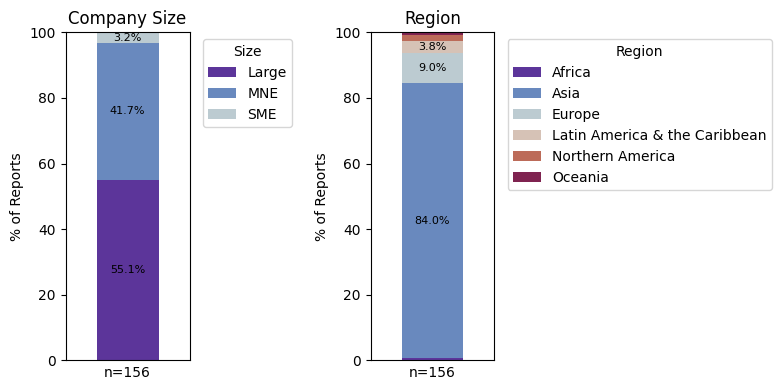

In [164]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))   # ví dụ 2 subplot

(conglomerates_size
 .set_index("Size")["percent"]
 .to_frame()
 .T
 .plot(kind="bar", 
      stacked=True, 
      ax=ax[0],                 # Plot 1        
      legend=True, 
      color = sns.color_palette("twilight_shifted")))
      
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="black")

ax[0].set_title("Company Size")
ax[0].legend(title="Size", bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("% of Reports")
ax[0].set_xlabel('n=156')
ax[0].set_xticks([])
ax[0].set_ylim(0,100)

(conglomerates_region
 .set_index("Region")["percent"]
 .to_frame()
 .T
 .plot(kind="bar",
       stacked=True,
       ax=ax[1],                 # Plot 2        
       legend=True,
       color=sns.color_palette("twilight_shifted"))
)
for container in ax[1].containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 2 else "" 
              for v in container]
    ax[1].bar_label(container, labels=labels, label_type="center", fontsize=8, color="black")

ax[1].set_title("Region")
ax[1].set_ylabel("% of Reports")
ax[1].set_xlabel("n=156")
ax[1].set_xticks([])
ax[1].set_ylim(0,100)
ax[1].legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Number of Reports')

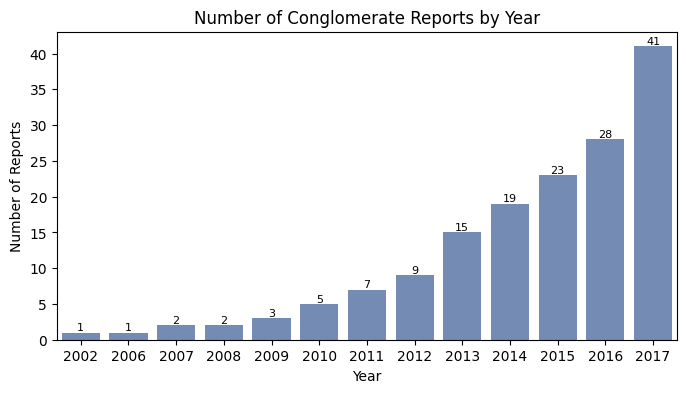

In [177]:
plt.figure(figsize=(8,4))
sns.barplot(data=conglomerates_years, x="Year", y="count", color=sns.color_palette("twilight_shifted")[1])
plt.bar_label(plt.gca().containers[0], fmt="%d", fontsize=8)
plt.title("Number of Conglomerate Reports by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reports")

### **Data population change over the pipeline**


In [30]:
data_summary_report = pd.DataFrame({
    'Metric': [
        'with images',
        'without images'
        ],
    'Value': [
        len(images_df['file'].unique()),
        len(selected_gri) - len(images_df['file'].unique())
    ]})
data_summary_report['percent'] = (data_summary_report['Value'] / data_summary_report['Value'].sum() * 100).round(1)

In [31]:
data_summary_images = pd.DataFrame({
    'Metric': [
        'with human',
        'without human'
        ],
    'Value': [
        len(images_with_human),
        len(images_df) - len(images_with_human)
    ]})
data_summary_images['percent'] = (data_summary_images['Value'] / data_summary_images['Value'].sum() * 100).round(1)

In [32]:
data_summary_human = pd.DataFrame({
    'Metric': [
        'faces detected',
        'cannot detect faces'
        ],
    'Value': [
        images_with_human['faces_detected'].sum(),
        images_with_human['humans_detected'].sum() - images_with_human['faces_detected'].sum()
    ]})
data_summary_human['percent'] = (data_summary_human['Value'] / data_summary_human['Value'].sum() * 100).round(1)

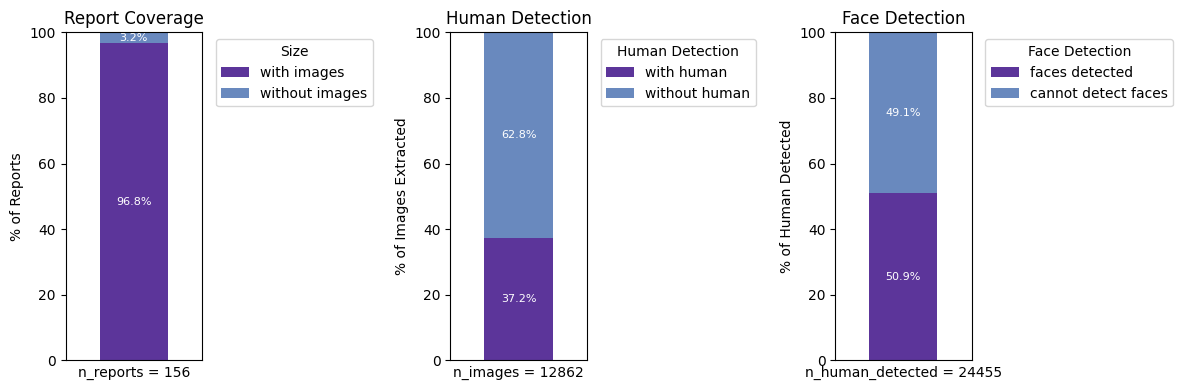

In [161]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

(data_summary_report
 .set_index("Metric")["percent"]
 .to_frame()
 .T
 .plot(kind="bar", 
      stacked=True, 
      ax=ax[0],                 # Plot 1        
      legend=True,
      color = sns.color_palette("twilight_shifted")))
      
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="white")

ax[0].set_title("Report Coverage")
ax[0].legend(title="Size", bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("% of Reports")
ax[0].set_xlabel('n_reports = 156')
ax[0].set_xticks([])
ax[0].set_ylim(0,100)

(data_summary_images
 .set_index("Metric")["percent"]
 .to_frame()
 .T
 .plot(kind="bar",
       stacked=True,
       ax=ax[1],                 # Plot 2        
       legend=True,
       color=sns.color_palette("twilight_shifted"))
)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="white")

ax[1].set_title("Human Detection")
ax[1].set_ylabel("% of Images Extracted")
ax[1].set_xlabel("n_images = 12862")
ax[1].set_xticks([])
ax[1].set_ylim(0,100)
ax[1].legend(title="Human Detection", bbox_to_anchor=(1.05, 1), loc='upper left')

(data_summary_human
 .set_index("Metric")["percent"]
 .to_frame()
 .T
 .plot(kind="bar",
       stacked=True,
       ax=ax[2],                 # Plot 3        
       legend=True,
       color=sns.color_palette("twilight_shifted"))
)
for container in ax[2].containers:
    ax[2].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="white")

ax[2].set_title("Face Detection")
ax[2].set_ylabel("% of Human Detected")
ax[2].set_xlabel("n_human_detected = 24455")
ax[2].set_xticks([])
ax[2].set_ylim(0,100)
ax[2].legend(title="Face Detection", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

### **Descriptive analysis of human representative**

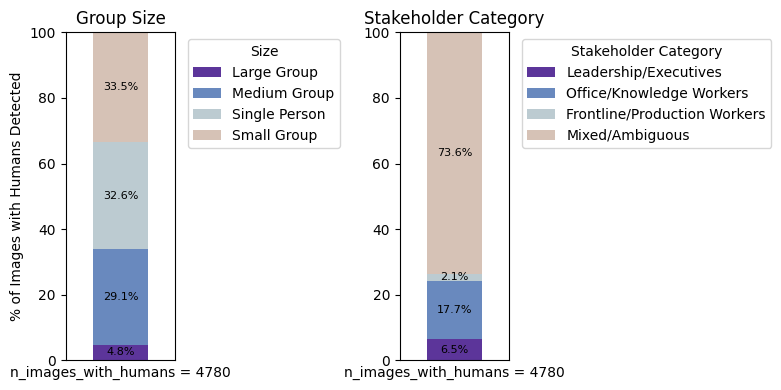

In [159]:
# Classification of images with humans detected
fig, ax = plt.subplots(1, 2, figsize=(8,4))

(image_summary_size
 .set_index("Group Size")["percent"]
 .to_frame()
 .T
 .plot(kind="bar", 
      stacked=True, 
      ax=ax[0],                 # Plot 1        
      legend=True, 
      color = sns.color_palette("twilight_shifted")))
      
for container in ax[0].containers:
    ax[0].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="black")

ax[0].set_title("Group Size")
ax[0].legend(title="Size", bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("% of Images with Humans Detected")
ax[0].set_xlabel('n_images_with_humans = 4780')
ax[0].set_xticks([])
ax[0].set_ylim(0,100)

(image_summary_stakeholder
 .set_index("Stakeholder Category")["percent"]
 .to_frame()
 .T
 .plot(kind="bar",
       stacked=True,
       ax=ax[1],                 # Plot 2        
       legend=True,
       color=sns.color_palette("twilight_shifted"))
)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="black")

ax[1].set_title("Stakeholder Category")
#ax[1].set_ylabel("% of Images with Humans Detected")
ax[1].set_xlabel("n_images_with_humans = 4780")
ax[1].set_xticks([])
ax[1].set_ylim(0,100)
ax[1].legend(title="Stakeholder Category", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


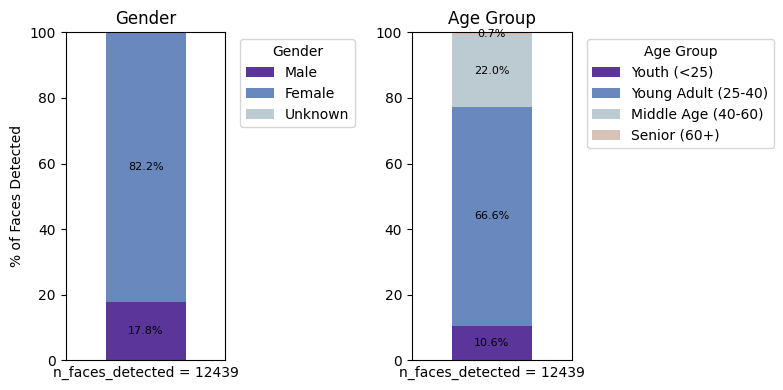

In [178]:
# Classification of faces detected
fig, ax = plt.subplots(1, 2, figsize=(8,4))

(image_summary_gender
 .set_index("Gender")["percent"]
 .to_frame()
 .T
 .plot(kind="bar", 
      stacked=True, 
      ax=ax[0],                 # Plot 1        
      legend=True, 
      color = sns.color_palette("twilight_shifted")))
      
for container in ax[0].containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 2 else "" 
              for v in container]
    ax[0].bar_label(container, labels=labels, label_type="center", fontsize=8, color="black")

ax[0].set_title("Gender")
ax[0].legend(title="Gender", bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("% of Faces Detected")
ax[0].set_xlabel('n_faces_detected = 12439')
ax[0].set_xticks([])
ax[0].set_ylim(0,100)

(image_summary_age
 .set_index("Age Group")["percent"]
 .to_frame()
 .T
 .plot(kind="bar",
       stacked=True,
       ax=ax[1],                 # Plot 2        
       legend=True,
       color=sns.color_palette("twilight_shifted"))
)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%.1f%%", label_type="center", fontsize=8, color="black")

ax[1].set_title("Age Group")
#ax[1].set_ylabel("% of Images with Humans Detected")
ax[1].set_xlabel("n_faces_detected = 12439")
ax[1].set_xticks([])
ax[1].set_ylim(0,100)
ax[1].legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### **Distribution of Image per Report**

In [59]:
# Distribution of image counts per report:
# 1) total extracted images
# 2) images with at least one human detected
report_image_counts = images_df.groupby("file").agg({'image_filename': 'count'}).reset_index()\
    .rename(columns={'image_filename': 'total_images'})

report_human_counts = images_with_human.groupby("file").agg({'image_filename': 'count'}).reset_index()\
    .rename(columns={'image_filename': 'human_images'})


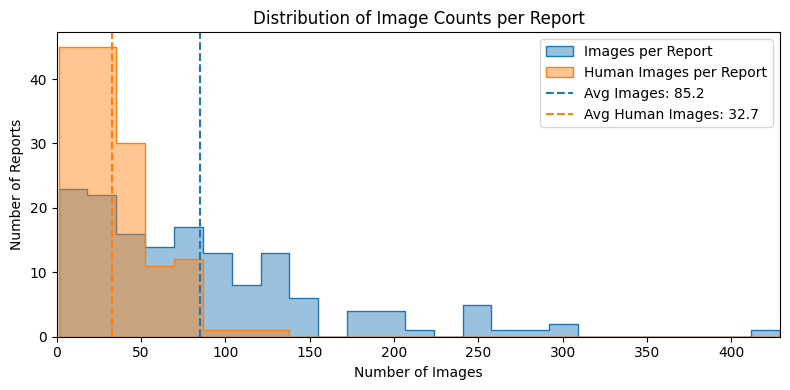

In [ ]:
all_values = np.concatenate([
    report_image_counts['total_images'].values,
    report_human_counts['human_images'].values
])

bins = np.histogram_bin_edges(all_values, bins='fd')  # Freedman–Diaconis

plt.figure(figsize=(8,4))
sns.histplot(data = report_image_counts, x='total_images', bins=bins, common_norm=False, alpha=0.45, element="step", label='Images per Report')
sns.histplot(data = report_human_counts, x='human_images', bins=bins, common_norm=False, alpha=0.45, element="step", label='Human Images per Report')
plt.axvline(report_image_counts['total_images'].mean(), color='tab:blue', linestyle='--', label=f"Avg Images: {report_image_counts['total_images'].mean():.1f}")
plt.axvline(report_human_counts['human_images'].mean(), color='tab:orange', linestyle='--', label=f"Avg Human Images: {report_human_counts['human_images'].mean():.1f}")
plt.legend()
plt.title("Distribution of Image Counts per Report")
plt.xlabel("Number of Images")
plt.ylabel("Number of Reports")
plt.xlim(0, report_image_counts['total_images'].max())
plt.tight_layout()
plt.show()


### **Trend**

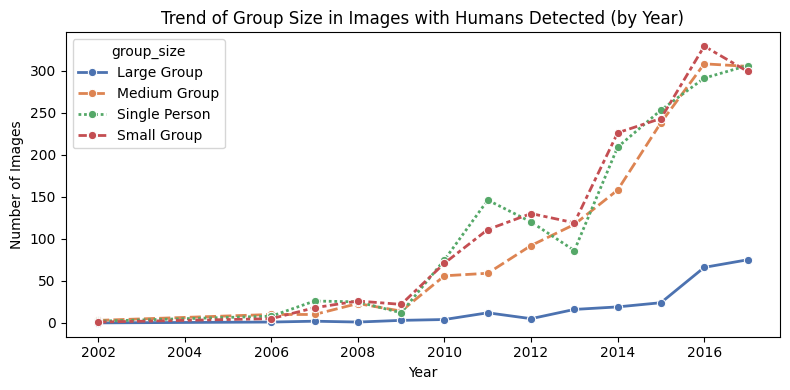

In [ ]:
# Who gets presented in the images? (by group size)
trend_by_size = images_with_human.groupby(['year','group_size']).agg({'image_filename': 'count'})
trend_by_size_pivot = trend_by_size.reset_index().pivot(index='year', columns='group_size', values='image_filename').fillna(0)
trend_by_size_pivot

# plot
plt.figure(figsize=(8,4))
sns.lineplot(data=trend_by_size_pivot, palette="deep", linewidth=2, markers ='o')
plt.title("Trend of Group Size in Images with Humans Detected (by Year)")
plt.xlabel("Year")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.show()

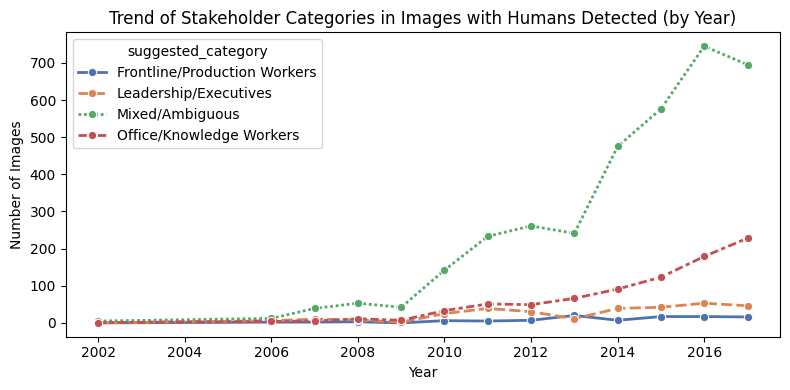

In [ ]:
# Who gets presented in the images? (by stakeholder category)
trend_by_stakeholder = images_with_human.groupby(['year','suggested_category']).agg({'image_filename': 'count'})
trend_by_stakeholder_pivot = trend_by_stakeholder.reset_index().pivot(index='year', columns='suggested_category', values='image_filename').fillna(0)
trend_by_stakeholder_pivot

# Plot
plt.figure(figsize=(8,4))
sns.lineplot(data=trend_by_stakeholder_pivot, palette="deep", linewidth=2, markers ='o')
plt.title("Trend of Stakeholder Categories in Images with Humans Detected (by Year)")
plt.xlabel("Year")
plt.ylabel("Number of Images")
plt.tight_layout()

plt.show()

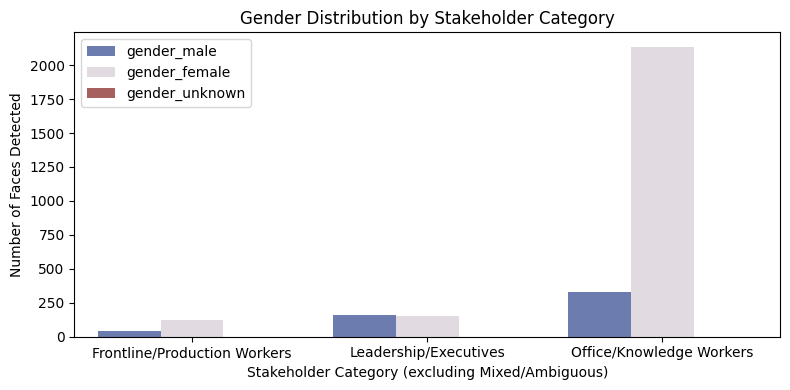

In [176]:
# Leader by Gender vs Other categories by gender
group_by_gender = images_with_human[images_with_human['suggested_category'] != 'Mixed/Ambiguous'].groupby(['suggested_category']).agg({
    'gender_male': 'sum',
    'gender_female': 'sum',
    'gender_unknown': 'sum'
}).reset_index()

group_gender_melted = group_by_gender.melt(
    id_vars="suggested_category",
    value_vars=["gender_male", "gender_female","gender_unknown"],
    var_name="gender",
    value_name="count"
)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=group_gender_melted, x='suggested_category', y='count', hue='gender', palette="twilight_shifted")
plt.legend()
plt.title("Gender Distribution by Stakeholder Category")
plt.xlabel("Stakeholder Category (excluding Mixed/Ambiguous)")
plt.ylabel("Number of Faces Detected")
plt.tight_layout()
plt.show()

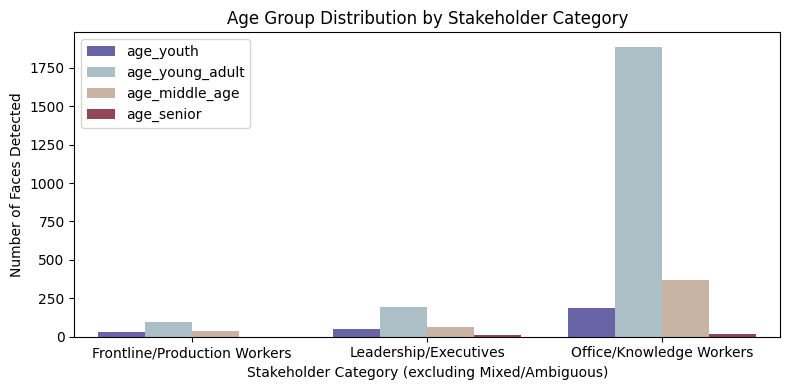

In [175]:
# Leader by age-group vs Other categories by age-group
group_by_age = images_with_human[images_with_human['suggested_category'] != 'Mixed/Ambiguous'].groupby(['suggested_category']).agg({
    'age_youth': 'sum',
    'age_young_adult': 'sum',
    'age_middle_age': 'sum',
    'age_senior': 'sum',}).reset_index()

group_age_melted = group_by_age.melt(
    id_vars="suggested_category",
    value_vars=["age_youth", "age_young_adult", "age_middle_age", "age_senior"],
    var_name="age_group",
    value_name="count"
)

# Plot
plt.figure(figsize=(8,4))
sns.barplot(data=group_age_melted, x='suggested_category', y='count', hue='age_group', palette="twilight_shifted")
plt.legend()
plt.title("Age Group Distribution by Stakeholder Category")
plt.xlabel("Stakeholder Category (excluding Mixed/Ambiguous)")
plt.ylabel("Number of Faces Detected")
plt.tight_layout()
plt.show()